Improt Libraries

In [7]:
# import libraries
import os
import random
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

Checking Images

D:/Project/Face_Emotion_Detection/original_dataset/train\angry


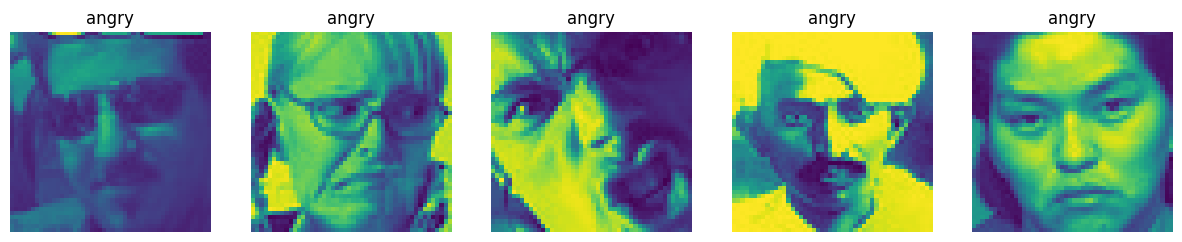

D:/Project/Face_Emotion_Detection/original_dataset/train\disgust


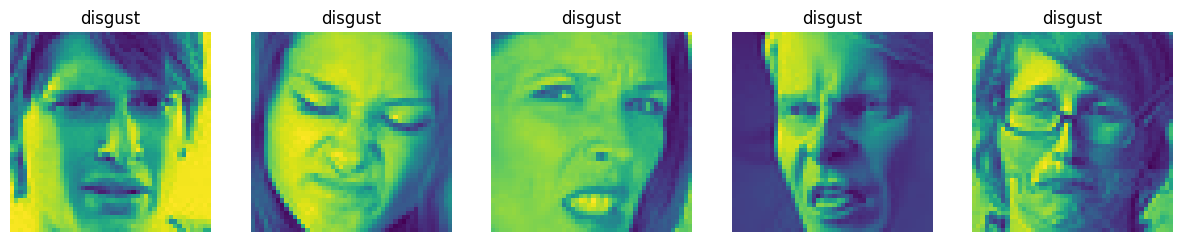

D:/Project/Face_Emotion_Detection/original_dataset/train\fear


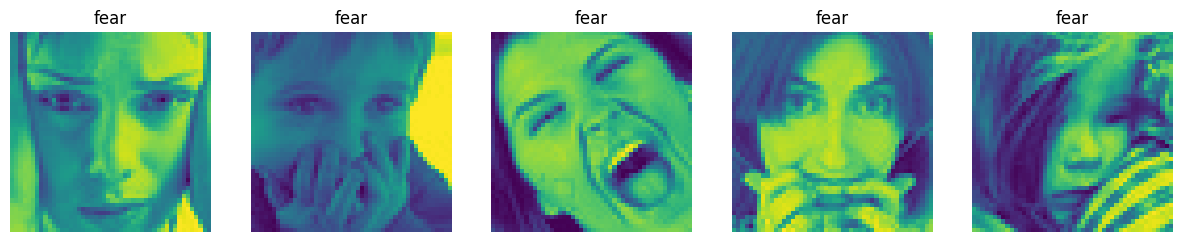

D:/Project/Face_Emotion_Detection/original_dataset/train\happy


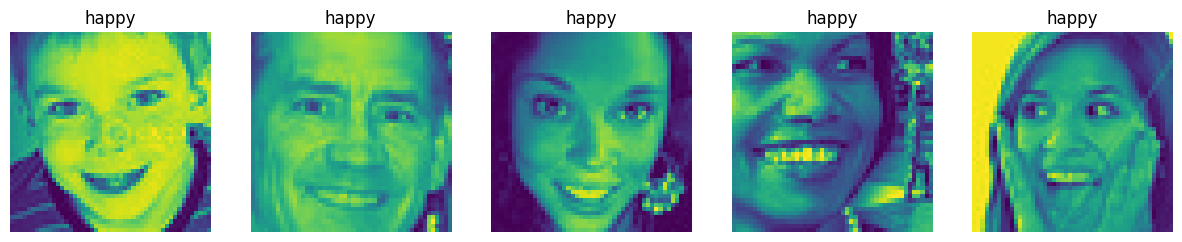

D:/Project/Face_Emotion_Detection/original_dataset/train\neutral


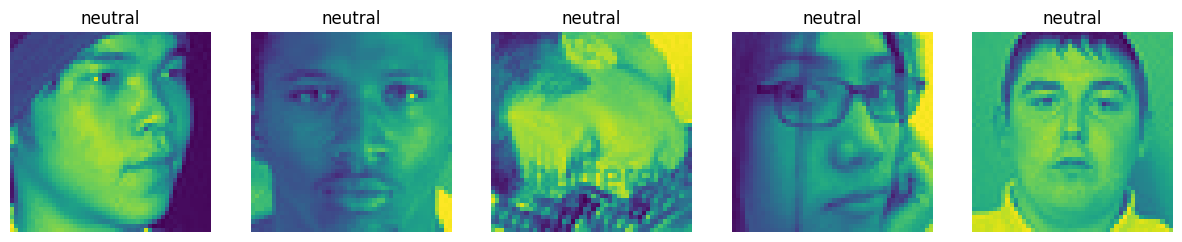

D:/Project/Face_Emotion_Detection/original_dataset/train\sad


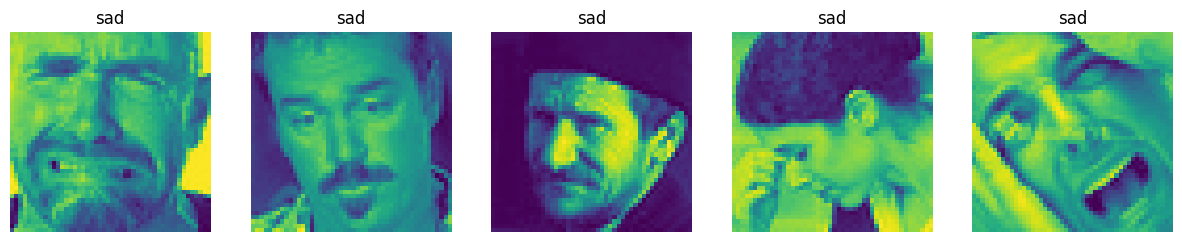

D:/Project/Face_Emotion_Detection/original_dataset/train\surprise


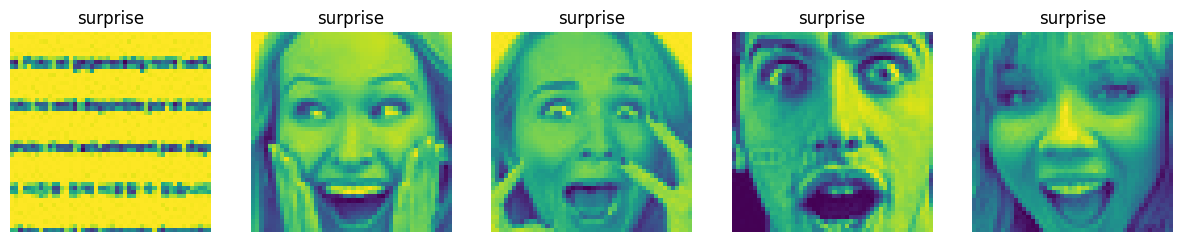

In [8]:
# random 5 images for training folder
train_dir = "D:/Project/Face_Emotion_Detection/original_dataset/train"
train_dir_classes = os.listdir(train_dir)

for classes in train_dir_classes:
    class_path = os.path.join(train_dir, classes)
    print(class_path)
    img_name = os.listdir(class_path)

    random5 = random.sample(img_name, 5)

    plt.figure(figsize=(15,3))
    for index, img in enumerate(random5):
        img_complete_path = os.path.join(class_path, img)
        img = Image.open(img_complete_path)

        plt.subplot(1, 5, index+1)
        plt.imshow(img)
        plt.title(classes)
        plt.axis("off")
    plt.show()

D:/Project/Face_Emotion_Detection/original_dataset/test\angry


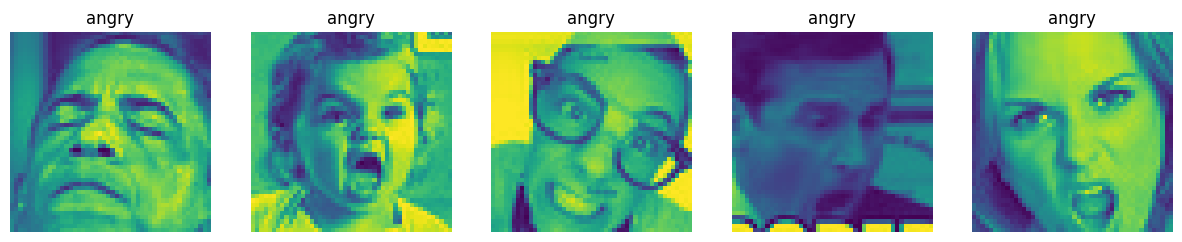

D:/Project/Face_Emotion_Detection/original_dataset/test\disgust


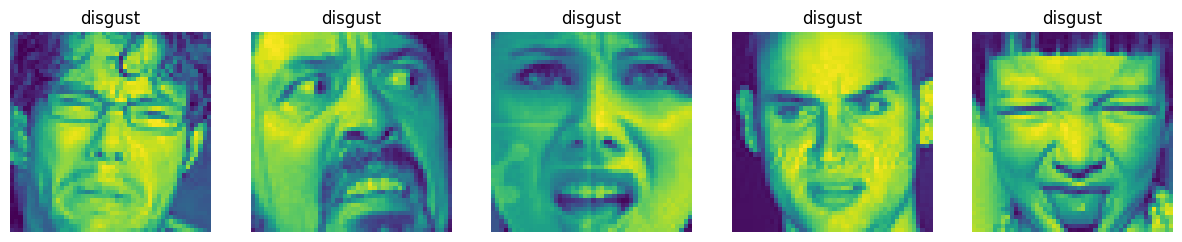

D:/Project/Face_Emotion_Detection/original_dataset/test\fear


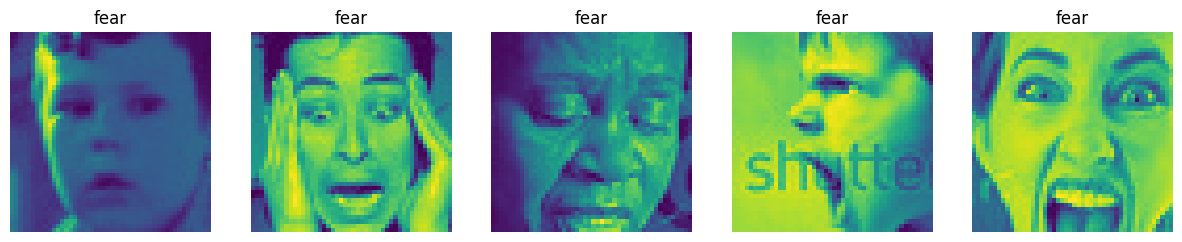

D:/Project/Face_Emotion_Detection/original_dataset/test\happy


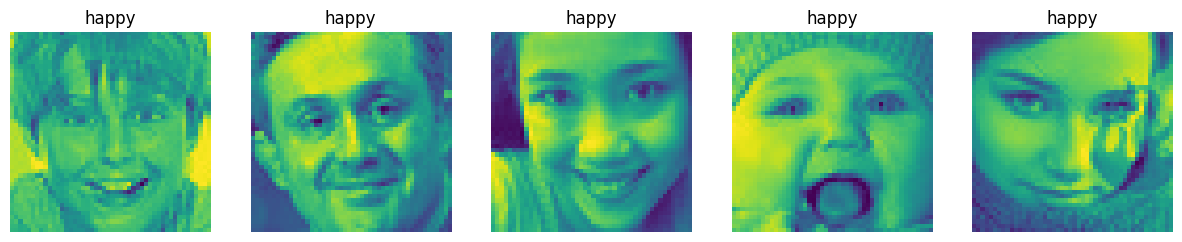

D:/Project/Face_Emotion_Detection/original_dataset/test\neutral


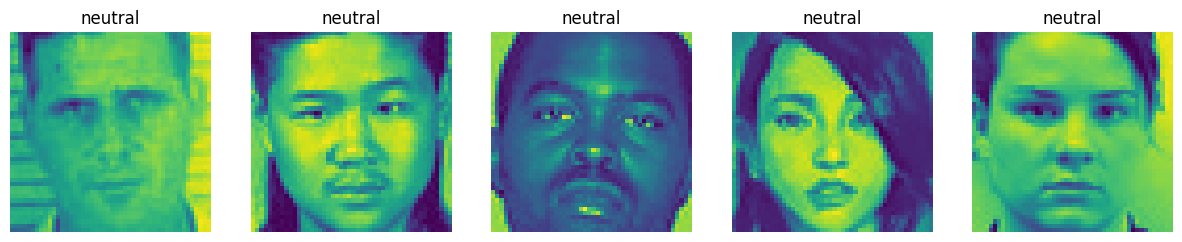

D:/Project/Face_Emotion_Detection/original_dataset/test\sad


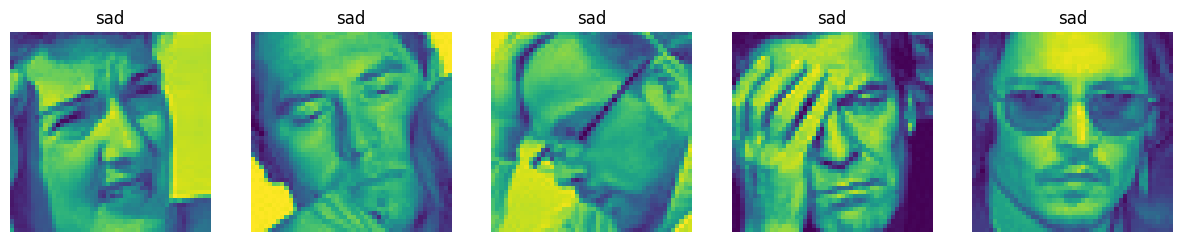

D:/Project/Face_Emotion_Detection/original_dataset/test\surprise


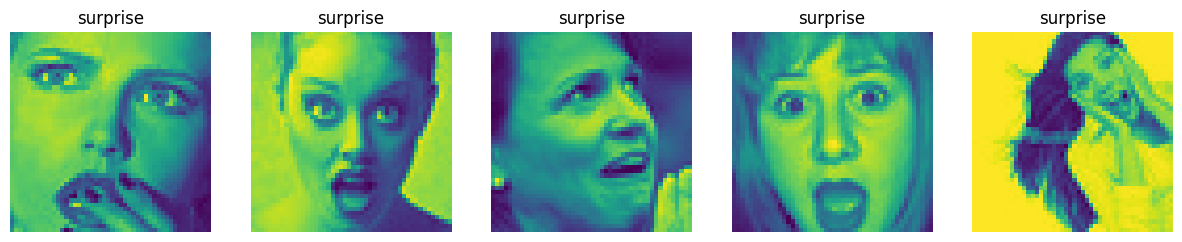

In [9]:
# random 5 images for testing folder
test_dir = "D:/Project/Face_Emotion_Detection/original_dataset/test"
test_dir_classes = os.listdir(test_dir)

for classes in test_dir_classes:
    class_path = os.path.join(test_dir, classes)
    print(class_path)
    img_name = os.listdir(class_path)

    random5 = random.sample(img_name, 5)

    plt.figure(figsize=(15,3))
    for index, img in enumerate(random5):
        img_complete_path = os.path.join(class_path, img)
        img = Image.open(img_complete_path)

        plt.subplot(1, 5, index+1)
        plt.imshow(img)
        plt.title(classes)
        plt.axis("off")
    plt.show()

Finding Number of Images

In [10]:
# Number of images in training folder
train_dir = "D:/Project/Face_Emotion_Detection/original_dataset/train"
train_dir_classes = os.listdir(train_dir)

for classes in train_dir_classes:

    class_path = os.path.join(train_dir, classes)

    img_name = os.listdir(class_path)
    print(f"Number of images in{classes}: {len(img_name)}")

Number of images inangry: 3995
Number of images indisgust: 436
Number of images infear: 4097
Number of images inhappy: 7215
Number of images inneutral: 4965
Number of images insad: 4830
Number of images insurprise: 3171


In [11]:
# Number of images in testing folder
test_dir = "D:/Project/Face_Emotion_Detection/original_dataset/test"
test_dir_classes = os.listdir(test_dir)

for classes in test_dir_classes:

    class_path = os.path.join(test_dir, classes)

    img_name = os.listdir(class_path)
    print(f"Number of images in{classes}: {len(img_name)}")

Number of images inangry: 958
Number of images indisgust: 111
Number of images infear: 1024
Number of images inhappy: 1774
Number of images inneutral: 1233
Number of images insad: 1247
Number of images insurprise: 831


Finding Dublicates Images

In [12]:
import hashlib

def hasher_images(file_path):
    hasher = hashlib.md5()
    with open(file_path, "rb") as f:
        img = f.read()
    hasher.update(img)
    return hasher.hexdigest()

dublicates = []
images = {}

for root, dirs, files in os.walk("D:/Project/Face_Emotion_Detection/original_dataset/train"):
    for file in files:
        img_path = os.path.join(root, file)
        hash_value = hasher_images(img_path)

        if hash_value in images:
            dublicates.append((hash_value, img_path))
        else:
            images[hash_value] = img_path

print(len(dublicates))

1236


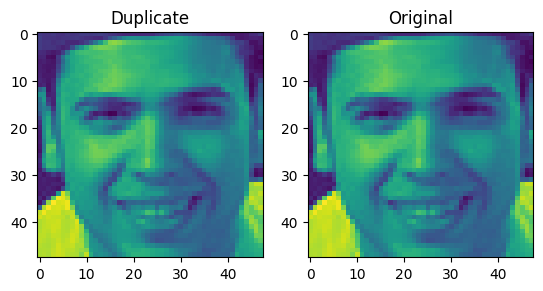

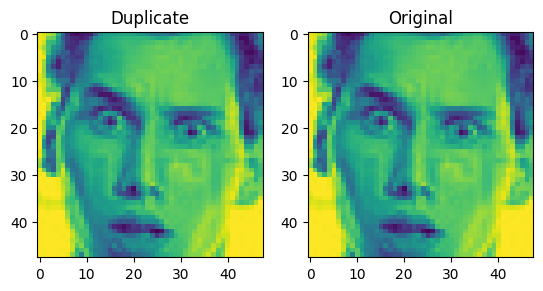

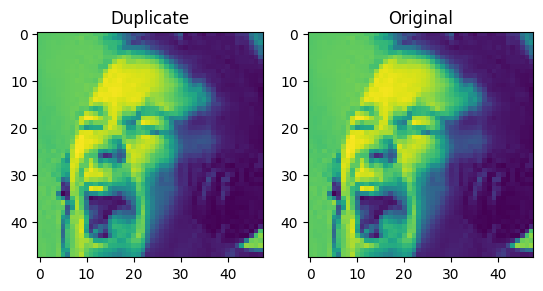

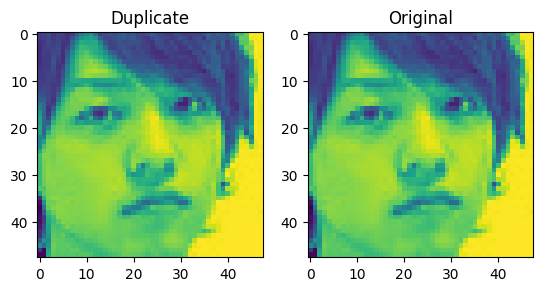

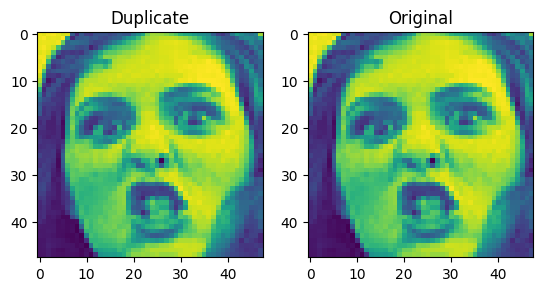

In [13]:
random5 = random.sample(dublicates, 5)

for hash_value, img_path in random5:
    dublicates_img_path = img_path
    original_img_path = images[hash_value]

    plt.Figure(figsize= (8,3))
    plt.subplot(1,2,1)
    dublicates_img = Image.open(dublicates_img_path)
    plt.imshow(dublicates_img)
    plt.title("Duplicate")

    plt.subplot(1,2,2)
    original_img = Image.open(original_img_path)
    plt.imshow(original_img)
    plt.title("Original")

    plt.show()

Removing Dublicates Images

In [14]:
import hashlib

def hasher_images(file_path):
    hasher = hashlib.md5()
    with open(file_path, "rb") as f:
        img = f.read()
    hasher.update(img)
    return hasher.hexdigest()

dublicates = []
images = {}

for root, dirs, files in os.walk("D:/Project/Face_Emotion_Detection/preprocessed_dataset/train"):
    for file in files:
        img_path = os.path.join(root, file)
        hash_value = hasher_images(img_path)

        if hash_value in images:
            dublicates.append((hash_value, img_path))
        else:
            images[hash_value] = img_path

print(len(dublicates))

0


In [15]:
dublicates_different_classes = 0

for hash_value, img_path in dublicates:
    dublicates_img_path = img_path
    original_img_path = images[hash_value]

    # Normalize the path to handle windows backslash
    dublicates_img_norm = os.path.normpath(os.path.split(dublicates_img_path)[0])
    original_img_norm = os.path.normpath(os.path.split(original_img_path)[0])

    # Split the directory compenents
    dublicates_img_class = dublicates_img_norm.split(os.sep)[-1]
    original_img_path = original_img_norm.split(os.sep)[-1]

    if dublicates_img_class != original_img_path:
        dublicates_different_classes +=1
        print("original_emotion:", original_img_path)
        print("dublicates_emotion:", dublicates_img_class)

print(dublicates_different_classes)

0


In [16]:
# Removing Dublicates from Training Folder
for hash_value, img_path in dublicates:
    dublicates_img_path = img_path

    if os.path.exists(dublicates_img_path):
        try:
            os.remove(dublicates_img_path)
        except Exception as e:
            print("Error while removing", e)

print("Dublicates Images are removed")

Dublicates Images are removed


In [17]:
import hashlib

def hasher_images(file_path):
    hasher = hashlib.md5()
    with open(file_path, "rb") as f:
        img = f.read()
    hasher.update(img)
    return hasher.hexdigest()

dublicates = []
images = {}

for root, dirs, files in os.walk("D:/Project/Face_Emotion_Detection/preprocessed_dataset/test"):
    for file in files:
        img_path = os.path.join(root, file)
        hash_value = hasher_images(img_path)

        if hash_value in images:
            dublicates.append((hash_value, img_path))
        else:
            images[hash_value] = img_path

print(len(dublicates))

0


In [18]:
# Removing Dublicates from Testing Folder
for hash_value, img_path in dublicates:
    dublicates_img_path = img_path

    if os.path.exists(dublicates_img_path):
        try:
            os.remove(dublicates_img_path)
        except Exception as e:
            print("Error while removing", e)

print("Dublicates Images are removed")

Dublicates Images are removed


In [19]:
import hashlib

def hasher_images(file_path):
    hasher = hashlib.md5()
    with open(file_path, "rb") as f:
        img = f.read()
    hasher.update(img)
    return hasher.hexdigest()

dublicates = []
images = {}

for root, dirs, files in os.walk("D:/Project/Face_Emotion_Detection/preprocessed_dataset/test"):
    for file in files:
        img_path = os.path.join(root, file)
        hash_value = hasher_images(img_path)

        if hash_value in images:
            dublicates.append((hash_value, img_path))
        else:
            images[hash_value] = img_path

print(len(dublicates))

0


Checking Curropt Images

In [20]:
# Finding Corrupt images From training folder
for root, dirs, files in os.walk("D:/Project/Face_Emotion_Detection/preprocessed_dataset/train"):
    for file in files:
        img_path = os.path.join(root, file)

        try:
            with open(img_path, 'rb') as img:
                image = Image.open(img_path)
                image.verify()
        except Exception as e:
            print("Error",e)
            print("img_path")
print("Curropt images checked")

Curropt images checked


In [21]:
# Finding Corrupt images From testing folder
for root, dirs, files in os.walk("D:/Project/Face_Emotion_Detection/preprocessed_dataset/test"):
    for file in files:
        img_path = os.path.join(root, file)

        try:
            with open(img_path, 'rb') as img:
                image = Image.open(img_path)
                image.verify()
        except Exception as e:
            print("Error",e)
            print("img_path")
print("Curropt images checked")

Curropt images checked


Finding Images Format

In [22]:
for root, dirs, files in os.walk("D:/Project/Face_Emotion_Detection/preprocessed_dataset/train"):
    unique_files = []
    for file in files:
        img_path = os.path.join(root, file)

        img_path_splitted = os.path.split(img_path)[-1].split(".")[-1]
        if img_path_splitted not in unique_files:
            unique_files.append(img_path_splitted)
        print(f"Unique image in {root}: {img_path_splitted}")
        print("-"*80)

Unique image in D:/Project/Face_Emotion_Detection/preprocessed_dataset/train\angry: jpg
--------------------------------------------------------------------------------
Unique image in D:/Project/Face_Emotion_Detection/preprocessed_dataset/train\angry: jpg
--------------------------------------------------------------------------------
Unique image in D:/Project/Face_Emotion_Detection/preprocessed_dataset/train\angry: jpg
--------------------------------------------------------------------------------
Unique image in D:/Project/Face_Emotion_Detection/preprocessed_dataset/train\angry: jpg
--------------------------------------------------------------------------------
Unique image in D:/Project/Face_Emotion_Detection/preprocessed_dataset/train\angry: jpg
--------------------------------------------------------------------------------
Unique image in D:/Project/Face_Emotion_Detection/preprocessed_dataset/train\angry: jpg
-------------------------------------------------------------------

In [23]:
for root, dirs, files in os.walk("D:/Project/Face_Emotion_Detection/preprocessed_dataset/test"):
    unique_files = []
    for file in files:
        img_path = os.path.join(root, file)

        img_path_splitted = os.path.split(img_path)[-1].split(".")[-1]
        if img_path_splitted not in unique_files:
            unique_files.append(img_path_splitted)
        print(f"Unique image in {root}: {img_path_splitted}")
        print("-"*80)

Unique image in D:/Project/Face_Emotion_Detection/preprocessed_dataset/test\angry: jpg
--------------------------------------------------------------------------------
Unique image in D:/Project/Face_Emotion_Detection/preprocessed_dataset/test\angry: jpg
--------------------------------------------------------------------------------
Unique image in D:/Project/Face_Emotion_Detection/preprocessed_dataset/test\angry: jpg
--------------------------------------------------------------------------------
Unique image in D:/Project/Face_Emotion_Detection/preprocessed_dataset/test\angry: jpg
--------------------------------------------------------------------------------
Unique image in D:/Project/Face_Emotion_Detection/preprocessed_dataset/test\angry: jpg
--------------------------------------------------------------------------------
Unique image in D:/Project/Face_Emotion_Detection/preprocessed_dataset/test\angry: jpg
-------------------------------------------------------------------------

Finding Pixel Size of Images

In [24]:
for root, dirs, files in os.walk("D:/Project/Face_Emotion_Detection/preprocessed_dataset/train"):
    unique_image_pixel_size = []
    for file in files:
        img_path = os.path.join(root, file)
        with open(img_path, 'rb') as img:
            image = Image.open(img_path)
            image_size = image.size
        if image_size not in unique_image_pixel_size:
            unique_image_pixel_size.append(image_size)

    print(f"Unique image size in {root}: {unique_image_pixel_size}")
    print("-"*80)

Unique image size in D:/Project/Face_Emotion_Detection/preprocessed_dataset/train: []
--------------------------------------------------------------------------------
Unique image size in D:/Project/Face_Emotion_Detection/preprocessed_dataset/train\angry: [(48, 48)]
--------------------------------------------------------------------------------
Unique image size in D:/Project/Face_Emotion_Detection/preprocessed_dataset/train\disgust: [(48, 48)]
--------------------------------------------------------------------------------
Unique image size in D:/Project/Face_Emotion_Detection/preprocessed_dataset/train\fear: [(48, 48)]
--------------------------------------------------------------------------------
Unique image size in D:/Project/Face_Emotion_Detection/preprocessed_dataset/train\happy: [(48, 48)]
--------------------------------------------------------------------------------
Unique image size in D:/Project/Face_Emotion_Detection/preprocessed_dataset/train\neutral: [(48, 48)]
------

In [25]:
for root, dirs, files in os.walk("D:/Project/Face_Emotion_Detection/preprocessed_dataset/test"):
    unique_image_pixel_size = []
    for file in files:
        img_path = os.path.join(root, file)
        with open(img_path, 'rb') as img:
            image = Image.open(img_path)
            image_size = image.size
        if image_size not in unique_image_pixel_size:
            unique_image_pixel_size.append(image_size)

    print(f"Unique image size in {root}: {unique_image_pixel_size}")
    print("-"*80)

Unique image size in D:/Project/Face_Emotion_Detection/preprocessed_dataset/test: []
--------------------------------------------------------------------------------
Unique image size in D:/Project/Face_Emotion_Detection/preprocessed_dataset/test\angry: [(48, 48)]
--------------------------------------------------------------------------------
Unique image size in D:/Project/Face_Emotion_Detection/preprocessed_dataset/test\disgust: [(48, 48)]
--------------------------------------------------------------------------------
Unique image size in D:/Project/Face_Emotion_Detection/preprocessed_dataset/test\fear: [(48, 48)]
--------------------------------------------------------------------------------
Unique image size in D:/Project/Face_Emotion_Detection/preprocessed_dataset/test\happy: [(48, 48)]
--------------------------------------------------------------------------------
Unique image size in D:/Project/Face_Emotion_Detection/preprocessed_dataset/test\neutral: [(48, 48)]
------------

Finding size of images From dataset

In [26]:
base_path = "D:/Project/Face_Emotion_Detection/preprocessed_dataset"
file_data = []
for root, dirs, files in os.walk(base_path):
    unique_image_file_size = []
    for file in files:
        img_path = os.path.join(root, file)
        try:
            size_kb =os.path.getsize(img_path)/1024
            file_data.append({
                "file_name": file,
                "folder": os.path.relpath(root, base_path),
                "size_kb": round(size_kb, 2)
            })
        except Exception as e:
            print(f"Error reading {img_path}: {e}")

df = pd.DataFrame(file_data)

df_sorted = df.sort_values(by="size_kb", ascending=False)
df_sorted

,file_name,folder,size_kb
1064,PrivateTest_1161501.jpg,test\fear,2.42
1057,PrivateTest_10306709.jpg,test\fear,2.34
14673,Training_87394233.jpg,train\fear,2.34
716,PublicTest_57272892.jpg,test\angry,2.31
10885,Training_98835403.jpg,train\angry,2.31
...,...,...,...
13616,Training_62764355.jpg,train\fear,0.55
9109,Training_5645946.jpg,train\angry,0.54
23735,Training_3542668.jpg,train\neutral,0.45
710,PublicTest_5543497.jpg,test\angry,0.35
